# Customer Segmentation - Unsupervised Learning 

## About the Data

This is a customer segmentation dataset containing various customer attributes. A description of the columns can be found here:
* CUST_ID - Credit card holder ID
* BALANCE_FREQUENCY - Ratio of last 12 months with balance. (1: Frequently updated, 0: Not frequently updated)
* PURCHASES - Total purchase amount spent during last 12 months
* ONEOFF_PURCHASES - Total amount of one-off purchases
* INSTALLMENTS_PURCHASES - Total amount of installment purchases
* CASH_ADVANCE - Total cash-advance amount
* PURCHASES_FREQUENCY - Frequency of purchases (Percent of months with at least one purchase). (1: Frequently purchased, 0: Not frequently purchased)
* ONEOFF_PURCHASES_FREQUENCY - Frequency of one-off-purchases. (1: Frequently purchased, 0: Not frequently purchased)
* PURCHASES_INSTALLMENTS_FREQUENCY - Frequency of installment purchases. (1: Frequently purchased, 0: Not frequently purchased)
* CASHADVANCE_FREQUENCY - Cash-advance frequency
* CASH_ADVANCE_TRX - Average amount per cash-advance transaction
* PURCHASES_TRX - Average amount per purchase transaction
* CREDIT_LIMIT - Credit Limit
* PAYMENTS - Total payments (Due amount paid by the customer to decrease their statement balance) in the period
* MINIMUM_PAYMENTS - Total minimum payments due in the period
* PRC_FULL_PAYMEN - Percentage of months with full payment of the due statement balance
* TENURE - Number of months as a customer

## Objective of the Analysis

The objective of this analysis is to categorise the customers into distinct groups based on shared characteristics. This will enable the company to target and tailor their marketing stragies to each group effectively. It will consist of at least three different unsupervised learning techniques in order to achieve this goal. At the end of the analysis, a summary will be provided which summarises the key findings and insights, and states the best model to use should the project be productionised.

## Analysis

### Import Data and Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
%matplotlib inline
import sklearn as skl
import seaborn as sns

In [5]:
data = pd.read_csv('Customer_Data.csv')
print(data.shape)
data.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### EDA & Data Pre-processing 

In [6]:
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
data.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

All the feature data types are numeric except the ID column, which is great so we can convert the full dataset to float for our analysis. We will however need to scale the data as we will likely use distance metrics in order to build our clusters, so we will need to scale in order to avoid misleading the algorithm.

#### Missing Data

In [8]:
missing_data = pd.DataFrame(data.isnull().sum().sort_values(ascending=False)).reset_index().rename(columns={'index':'feature', 0:'missing_values'})
missing_data = missing_data[missing_data['missing_values'] > 0]
missing_data

,feature,missing_values
0,MINIMUM_PAYMENTS,313
1,CREDIT_LIMIT,1


In [9]:
# replace missing data with the mean 
min_paym_mean = data['MINIMUM_PAYMENTS'].mean()
cred_lim_mean = data['CREDIT_LIMIT'].mean()

data['MINIMUM_PAYMENTS'].fillna(min_paym_mean, inplace=True)
data['CREDIT_LIMIT'].fillna(cred_lim_mean, inplace=True)

print(data.isna().sum())

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


#### Outliers

In [10]:
data_numeric = data.drop(columns='CUST_ID')

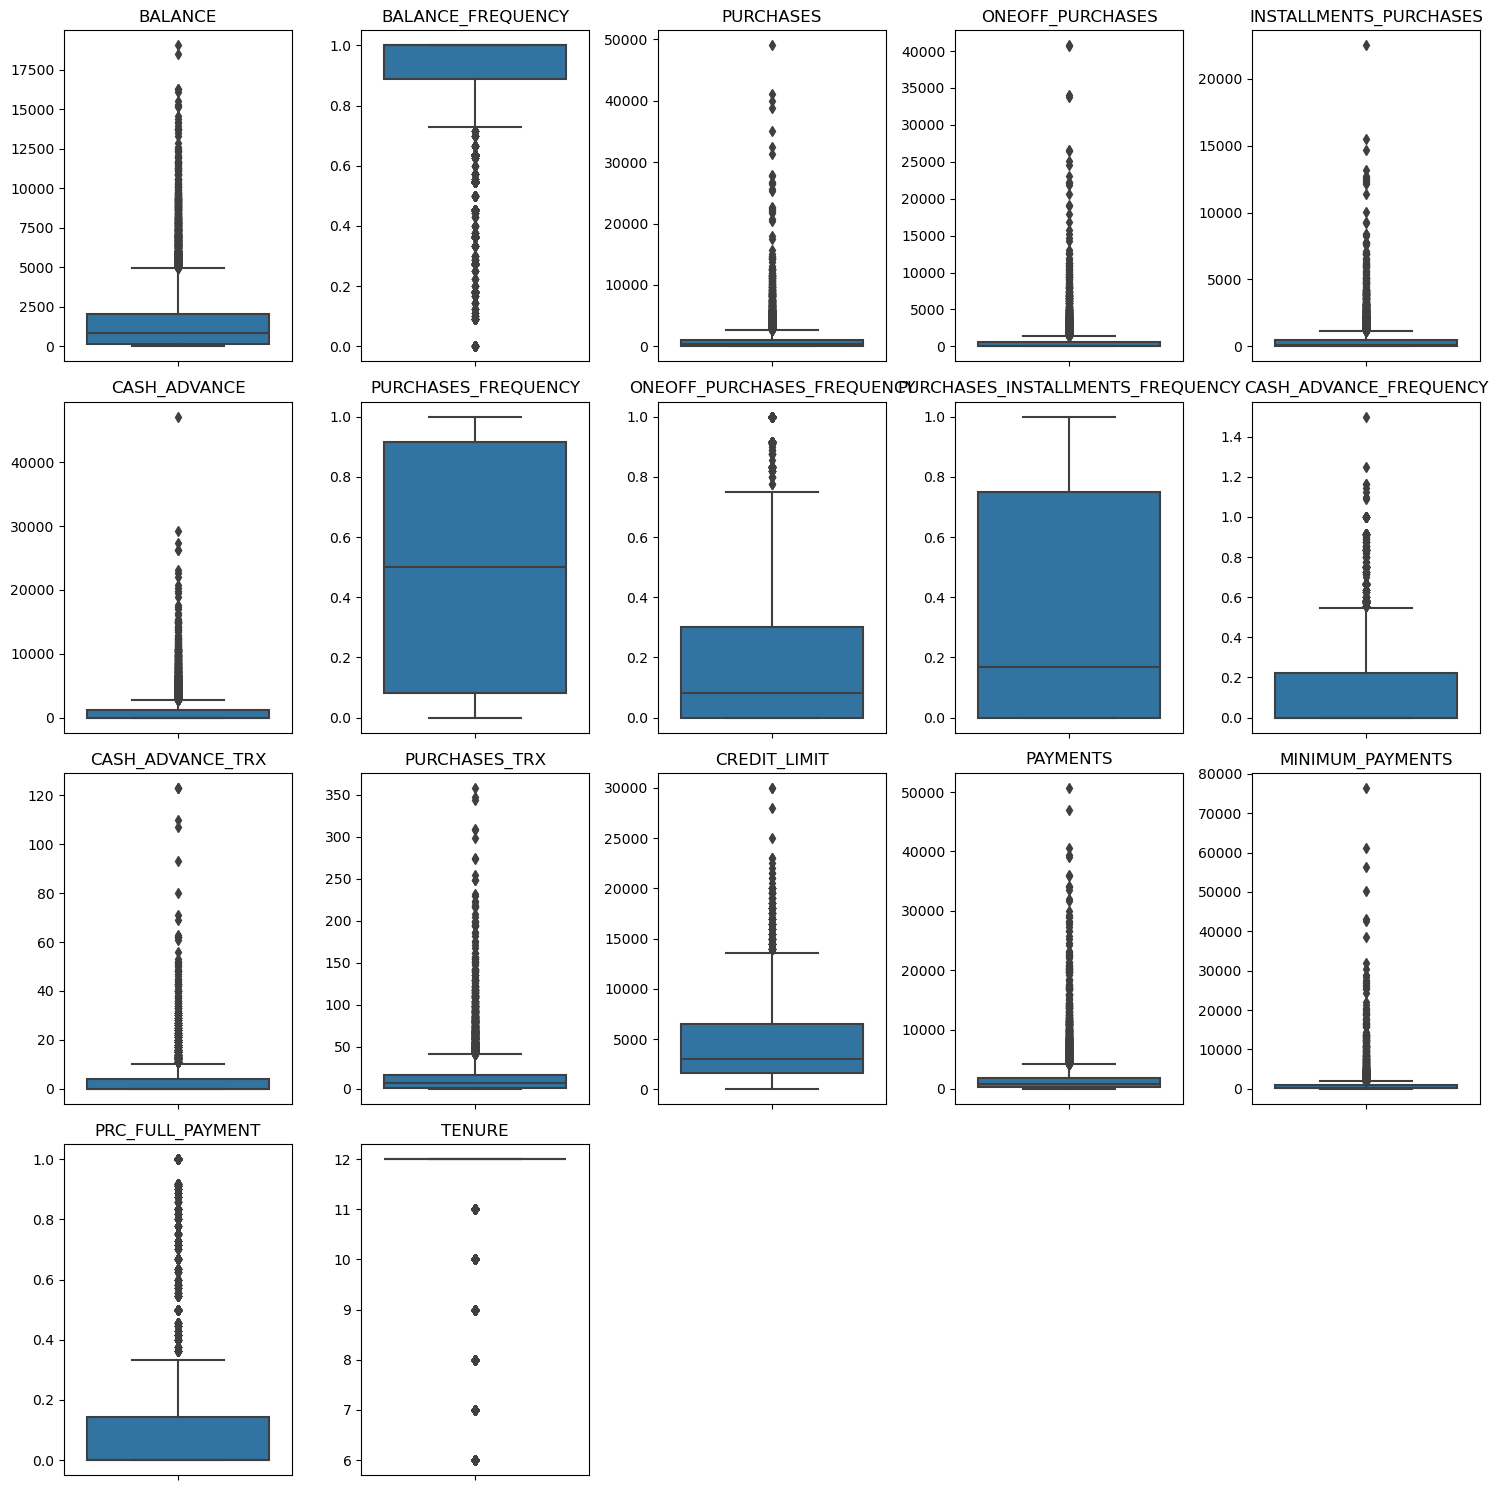

In [11]:
fig, axs = plt.subplots(nrows=4, ncols=5)
fig.set_size_inches(15, 15)

# Flatten the axs array to iterate over it
axs = axs.flatten()

# Iterate through both columns and axes
for i, col in enumerate(data_numeric.columns):
    sns.boxplot(data=data_numeric, y=col, ax=axs[i])
    axs[i].set_title(col)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')

# Hide any extra subplots if the number of columns is less than 16
for ax in axs[len(data_numeric.columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

By looking at the charts, it appears like there are some outliers in a lot of the features. We will need to handle them in order to use certain algorithms like K-means, as this algorithm in particular is very sensitive to outliers. A single extreme value can pull the cluster centroid away from the true center in this case.

Depending on the skewness of the data, we can use IQR or Z-score as the method for detecting outliers. If it is normally distributed then we can go with Z-score, else IQR would be preferable.

In [12]:
data_numeric.skew()

BALANCE                              2.393386
BALANCE_FREQUENCY                   -2.023266
PURCHASES                            8.144269
ONEOFF_PURCHASES                    10.045083
INSTALLMENTS_PURCHASES               7.299120
CASH_ADVANCE                         5.166609
PURCHASES_FREQUENCY                  0.060164
ONEOFF_PURCHASES_FREQUENCY           1.535613
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
CASH_ADVANCE_FREQUENCY               1.828686
CASH_ADVANCE_TRX                     5.721298
PURCHASES_TRX                        4.630655
CREDIT_LIMIT                         1.522549
PAYMENTS                             5.907620
MINIMUM_PAYMENTS                    13.867357
PRC_FULL_PAYMENT                     1.942820
TENURE                              -2.943017
dtype: float64

We'll use the IQR method as there appears to be a high degree of skewness present in the data.

In [13]:
# display counts and proportions of outliers for each feature
def detect_outliers_iqr(df):
    outlier_stats = []

    for col in df.select_dtypes(include=[np.number]):  # Process only numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound))
        outlier_count = outliers.sum()
        total_count = len(df[col])
        outlier_proportion = outlier_count / total_count

        outlier_stats.append({
            'Feature': col,
            'Outlier Count': outlier_count,
            'Outlier Proportion': round(outlier_proportion, 4)  # Rounded for readability
        })

    return pd.DataFrame(outlier_stats).sort_values(by="Outlier Proportion", ascending=False)

outlier_df = detect_outliers_iqr(data_numeric)
outlier_df

,Feature,Outlier Count,Outlier Proportion
1,BALANCE_FREQUENCY,1493,0.1668
15,PRC_FULL_PAYMENT,1474,0.1647
16,TENURE,1366,0.1526
5,CASH_ADVANCE,1030,0.1151
3,ONEOFF_PURCHASES,1013,0.1132
4,INSTALLMENTS_PURCHASES,867,0.0969
13,PAYMENTS,808,0.0903
2,PURCHASES,808,0.0903
10,CASH_ADVANCE_TRX,804,0.0898
7,ONEOFF_PURCHASES_FREQUENCY,782,0.0874


When we actually view the proportions of outliers in the features, there are only a handful - maximum of 17% using the IQR method. We will apply **Winsorization** and then use **StandardScaler** to normalise the data. We'll set the lower and upper limits to the 5th and 95th percentile. This is due to the fact that our data is quite heavily skewed and this method more aggressively targets extreme tails.

In [14]:
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler

# Winsorization function that preserves 0 values
def apply_winsorization(df, lower_pct=0.05, upper_pct=0.05):  
    df_winsorized = df.copy()

    for col in df_winsorized.select_dtypes(include=[np.number]):  # Apply only to numeric columns
        nonzero_mask = df_winsorized[col] != 0  # Identify nonzero values
        nonzero_values = df_winsorized[col][nonzero_mask]  # Extract nonzero values
        
        # Apply winsorization only to nonzero values
        winsorized_values = winsorize(nonzero_values, limits=(lower_pct, upper_pct))
        
        # Assign back winsorized values, keeping 0s untouched
        df_winsorized.loc[nonzero_mask, col] = winsorized_values
    
    return df_winsorized

df_winsorized = apply_winsorization(data_numeric)  

# df_scaled.head()
df_winsorized.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,56.00,45.65,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [15]:
print(df_winsorized.skew().sort_values(ascending=False))

ONEOFF_PURCHASES                    2.379118
CASH_ADVANCE                        2.174737
CASH_ADVANCE_TRX                    2.147501
INSTALLMENTS_PURCHASES              2.045069
PRC_FULL_PAYMENT                    1.942820
PURCHASES                           1.868167
PURCHASES_TRX                       1.801653
MINIMUM_PAYMENTS                    1.704406
PAYMENTS                            1.669384
ONEOFF_PURCHASES_FREQUENCY          1.535613
CASH_ADVANCE_FREQUENCY              1.473277
BALANCE                             1.390956
CREDIT_LIMIT                        0.942561
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
PURCHASES_FREQUENCY                 0.060164
BALANCE_FREQUENCY                  -1.915218
TENURE                             -2.592505
dtype: float64


As we can see, our new dataset is still quite skewed, although the degree of skewness has been reduced dramatically. We will need to address this skewness in order to run certain algorithms like K-means. But other unsupervised learning methods are much more robust with handling skewness. We can still transform the features for aggressively using **Power Transformer** to address the remaining skewness for the K-means. The Power Tranformer method will also address the scaling issue in the current dataset. This is crucial as the distance metrics in K-means will be sensitive to the scale of our data points.

### Data Exploration Summary and Action

**Data cleaning**
* there were only two columns that required handling **missing data** for: MINIMUM_PAYMENTS and CREDIT_LIMIT. Here I replaced missing values with the mean.
* the dataset had a large presence of **outliers**. To handle them I applied the **winsorization** method which set the lower and upper limits to the 5th and 95th percentile. This is due to the fact that our data is quite heavily skewed and this method more aggressively targets extreme tails.

### Modelling

#### K-means++ Clustering
*Sckit-learn already uses Kmeans++ by default*

In [16]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df_transformed = pd.DataFrame(pt.fit_transform(df_winsorized), columns=df_winsorized.columns)
df_transformed.skew()

BALANCE                            -0.144472
BALANCE_FREQUENCY                  -1.089921
PURCHASES                          -0.241143
ONEOFF_PURCHASES                    0.095944
INSTALLMENTS_PURCHASES             -0.038339
CASH_ADVANCE                        0.176185
PURCHASES_FREQUENCY                -0.044848
ONEOFF_PURCHASES_FREQUENCY          0.541358
PURCHASES_INSTALLMENTS_FREQUENCY    0.217056
CASH_ADVANCE_FREQUENCY              0.493439
CASH_ADVANCE_TRX                    0.385752
PURCHASES_TRX                      -0.016983
CREDIT_LIMIT                        0.003109
PAYMENTS                            0.035092
MINIMUM_PAYMENTS                    0.057152
PRC_FULL_PAYMENT                    0.963939
TENURE                             -1.949923
dtype: float64

In [17]:
round(df_transformed.describe(),4)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001
min,-2.1689,-1.9583,-1.5151,-1.0068,-1.0910,-0.9474,-1.2789,-0.9033,-1.0044,-0.8854,-0.9068,-1.3803,-1.5588,-2.6876,-1.7633,-0.6779,-2.4651
25%,-0.8543,-0.6491,-0.5972,-1.0068,-1.0910,-0.9474,-1.0159,-0.9033,-1.0044,-0.8854,-0.9068,-0.8887,-0.9413,-0.6867,-0.7740,-0.6779,0.4235
50%,0.1539,0.6325,0.1396,0.2745,0.3461,-0.9474,0.1197,-0.0922,-0.2738,-0.8854,-0.9068,0.1280,-0.1198,-0.0942,-0.0548,-0.6779,0.4235
75%,0.7515,0.6325,0.7366,0.9909,0.9093,1.0571,1.0503,0.9781,1.0699,1.0251,1.0492,0.7441,0.8837,0.6298,0.8335,0.8541,0.4235
max,1.6557,0.6325,1.7049,1.4752,1.4746,1.4124,1.2189,1.7326,1.3771,1.7588,1.6785,1.7895,1.6739,2.0136,1.7475,1.8736,0.4235


In [18]:
# Force no warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

# Setup and imports
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans

In [19]:
# helper function that allows us to display data in 2 dimensions and highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

Code below that calculates the inertia for 1 to 30 clusters, and plots the inertia as a function of the number of clusters. This will allow us to determine the appropriate number of clusters to use for our K-means algorithm.

Text(0, 0.5, 'Inertia')

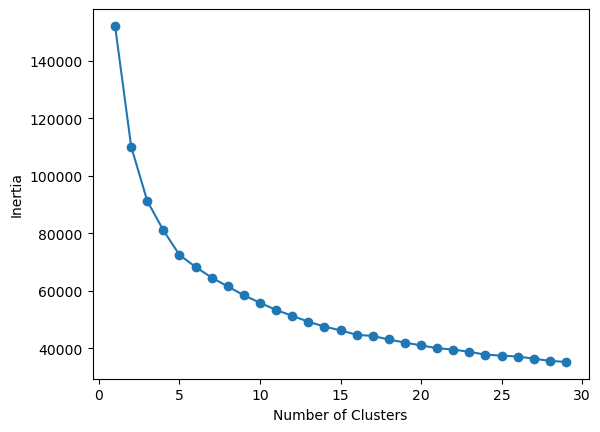

In [20]:
### BEGIN SOLUTION
inertia = []
list_num_clusters = list(range(1,30))
for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters)
    km.fit(df_transformed)
    inertia.append(km.inertia_)
    
plt.plot(list_num_clusters,inertia)
plt.scatter(list_num_clusters,inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
### END SOLUTION

The elbow point is around 5 but we can decrease the inertia slightly to about ~55,000 by expanding to 10 clusters. We wouldn't want to go much higher than that as we want to ensure enough insight can be extracted from the customer segments. Let's visualise the silhouette score for 8,10 and 12 clusters, to assess the quality of the clusters for each n_clusters value.

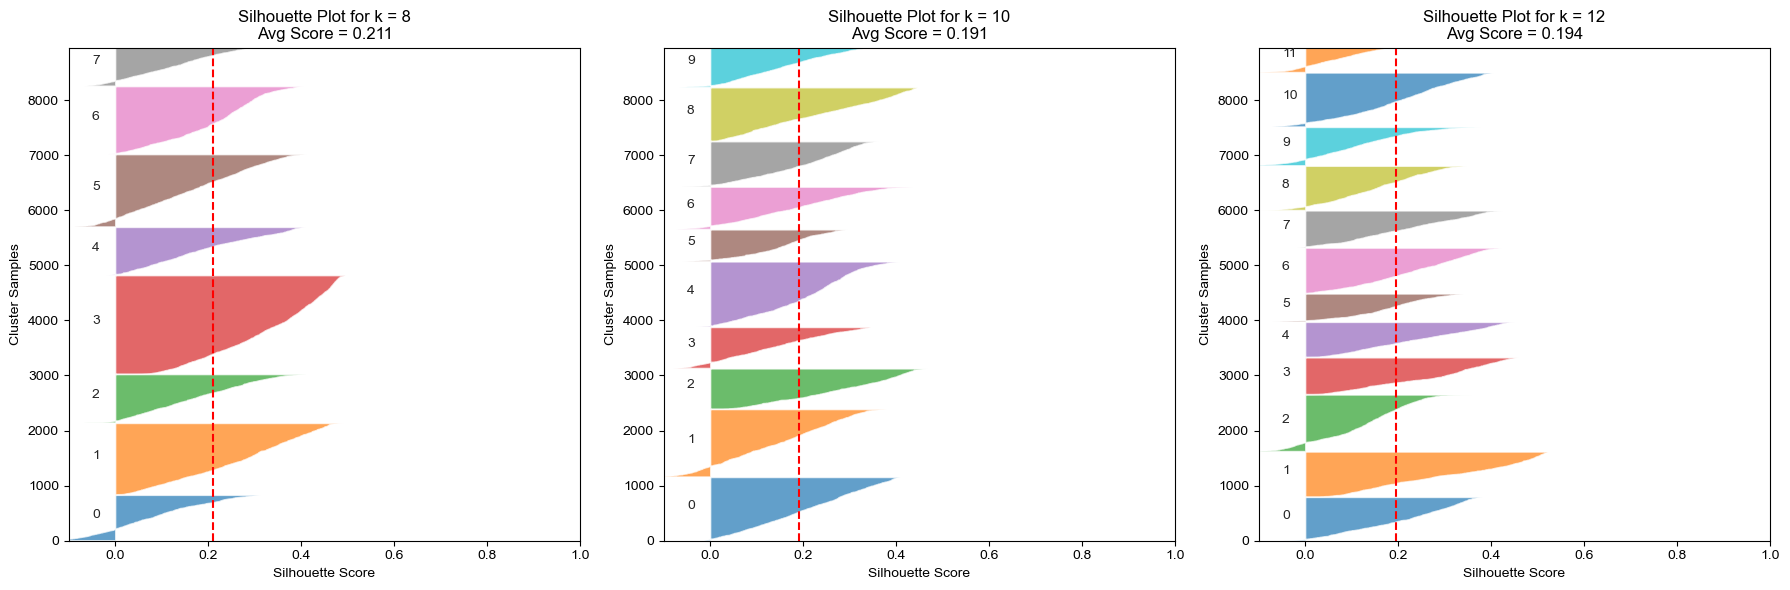

In [21]:
from sklearn.metrics import silhouette_samples, silhouette_score

# Define cluster values to test
cluster_options = [8, 10, 12]

# Set up visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_style("whitegrid")

# Loop through each cluster option
for idx, k in enumerate(cluster_options):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_transformed)
    
    # Compute silhouette scores
    silhouette_avg = silhouette_score(df_transformed, cluster_labels)
    sample_silhouette_values = silhouette_samples(df_transformed, cluster_labels)
    
    y_lower = 10  # Track y-axis position
    axes[idx].set_title(f"Silhouette Plot for k = {k}\nAvg Score = {silhouette_avg:.3f}")
    
    for i in range(k):
        # Collect silhouette scores for cluster i
        cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        cluster_silhouette_values.sort()
        
        size_cluster = cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster
        
        # Fill the silhouette plot
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values, alpha=0.7)
        
        # Label each cluster region
        axes[idx].text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        
        y_lower = y_upper + 10  # Add space between clusters
    
    axes[idx].axvline(x=silhouette_avg, color="red", linestyle="--")  # Avg score line
    axes[idx].set_xlabel("Silhouette Score")
    axes[idx].set_ylabel("Cluster Samples")
    axes[idx].set_xlim([-0.1, 1])
    axes[idx].set_ylim([0, len(df_transformed)])
    
plt.tight_layout()
plt.show()


**How to interpret the chart**
* Closer to +1 → Well-separated clusters ✅
* Near 0 → Overlapping clusters ⚠️
* Negative → Misclassified clusters ❌

* Wider silhouette bars = Better-defined clusters
* Narrow or negative silhouette bars = Poorly defined clusters
* Red dashed line = Average silhouette score for that k

Our silhouette score visualisation plot for the optimal number of clusters has shown that with this algorthm, the clusters overlap significantly and are not as spread out as we would like. We wouldn't want to increase the number of clusters much more than this as that would not be ideal for producing insightful customer segments. We'll be better of using a different algorithm for our analysis. 

### DBSCAN
*Density-Based Clustering of Applications with Noise*

We still need to scale our data for DBSCAN because the algorithm is distance-based. However, DBSCAN is less sensitive to outliers so we don't need to use the aggressive Power Transformer to reduce the skewness. We can thus use our **df_winsorized** object where the outliers are at least brought into proportion with the rest of the data.

In [22]:
## import libraries
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.metrics import silhouette_score
sns.set_context('notebook')
sns.set_style('white')

In [23]:
# apply PCA to reduce dimension of data
from sklearn.decomposition import PCA

# Reduce to 2 or 3 dimensions (for DBSCAN to work better)
pca = PCA(n_components=3, random_state=42)
df_pca = pca.fit_transform(df_winsorized)

In [24]:
# Define parameter ranges
eps_values = range(3,13)  
min_samples_values = range(3,13)  # min_samples from 3 to 12

# Store results
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_pca)
        
        # Ignore cases where all points are noise
        if len(set(labels)) <= 1:
            continue 
        
        # Compute silhouette score (ignoring noise points)
        silhouette_avg = silhouette_score(df_pca, labels) if len(set(labels)) > 1 else -1
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        num_noise = list(labels).count(-1)
        
        results.append((eps, min_samples, num_clusters, silhouette_avg, num_noise))

# Convert results to a DataFrame for easy visualization
df_results = pd.DataFrame(results, columns=["eps", "min_samples", "num_clusters", "silhouette", "num_noise"])

# Pivot table for heatmap
heatmap_data = df_results.pivot(columns=["eps", "min_samples", "silhouette"])

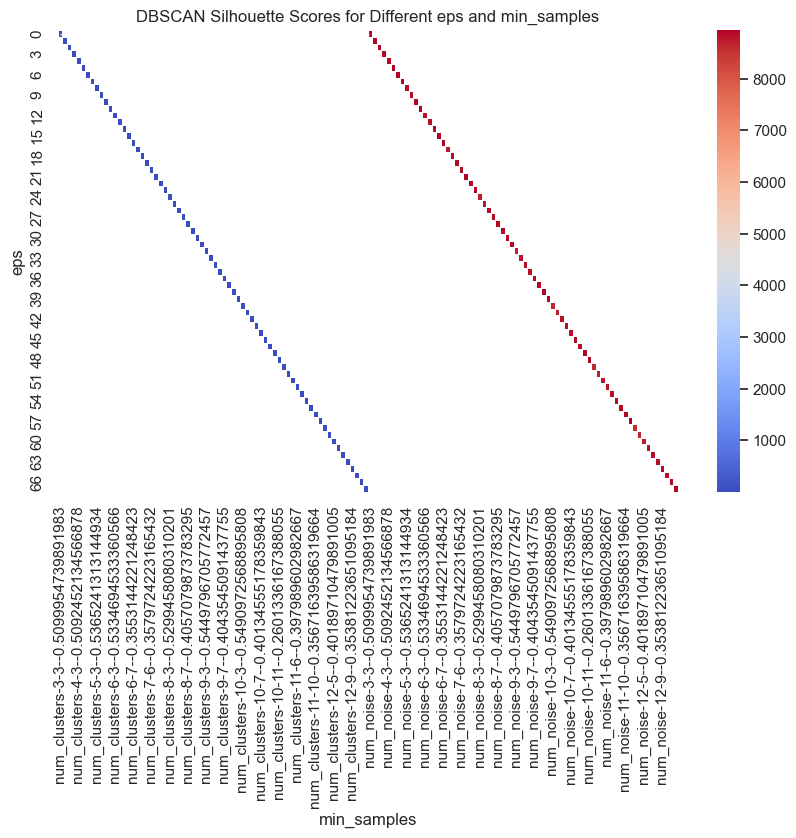

Best eps: 3.0, Best min_samples: 6.0
Best Number of Clusters: 1.0, Silhouette Score: -0.2096
Number of Noise Points: 8944.0


In [25]:
# Heatmap of silhouette scores
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f",linewidths=0.5) # 
plt.title("DBSCAN Silhouette Scores for Different eps and min_samples")
plt.xlabel("min_samples")
plt.ylabel("eps")
plt.show()

# Print the best parameters
best_params = df_results.loc[df_results["silhouette"].idxmax()]
print(f"Best eps: {best_params['eps']}, Best min_samples: {best_params['min_samples']}")
print(f"Best Number of Clusters: {best_params['num_clusters']}, Silhouette Score: {best_params['silhouette']:.4f}")
print(f"Number of Noise Points: {best_params['num_noise']}")

Judging by the results, it appears that DBSCAN is finding difficulty in determining enough dense regions that satisfy both the epsilon and min_samples values. If we were to try and iterate with this method we could try HDBSCAN, which can handle varying density clusters much better.

### Hierarchical Clustering

This clustering algorithm will try to continuously split out and merge new clusters successively until it reaches a level of convergence.

In [26]:
from sklearn.cluster import AgglomerativeClustering

# Fit model
agg = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')  # ward linkage computes the inertia and merges based on the best inertia
labels = agg.fit_predict(df_winsorized)

# Evaluate
sil_score = silhouette_score(df_winsorized, labels)
print(f"Silhouette Score (Agglomerative Clustering): {sil_score:.4f}")


Silhouette Score (Agglomerative Clustering): 0.3712


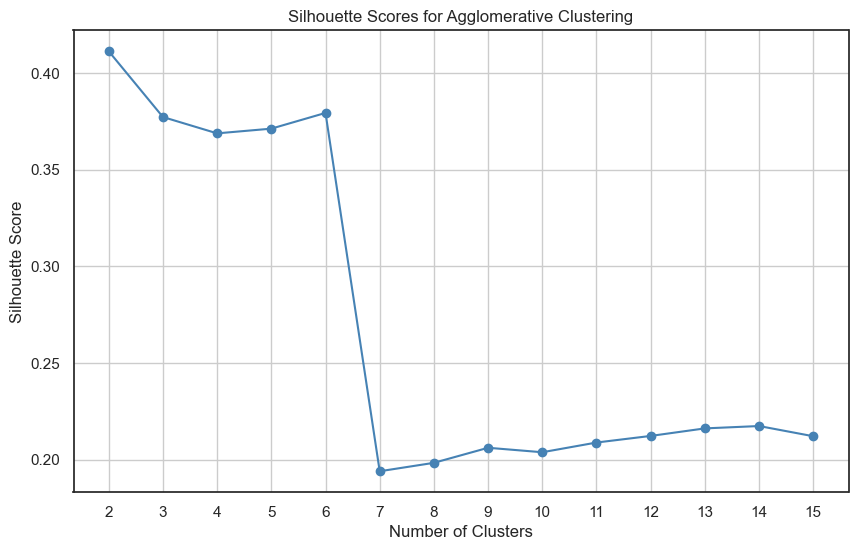

In [27]:
# Range of clusters to test
cluster_range = range(2, 16)
silhouette_scores = []

for n_clusters in cluster_range:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(df_winsorized)
    score = silhouette_score(df_winsorized, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-', color='steelblue')
plt.title("Silhouette Scores for Agglomerative Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.xticks(cluster_range)
plt.show()


#### Visualise the 6 clusters which had the best silhouette score

In [28]:
# Reduce data to 2D for visualization
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_winsorized)

In [29]:
# generate model and labels for 6 clusters
agg_model = AgglomerativeClustering(n_clusters=6, linkage='ward', affinity='euclidean')
cluster_labels = agg_model.fit_predict(df_winsorized)

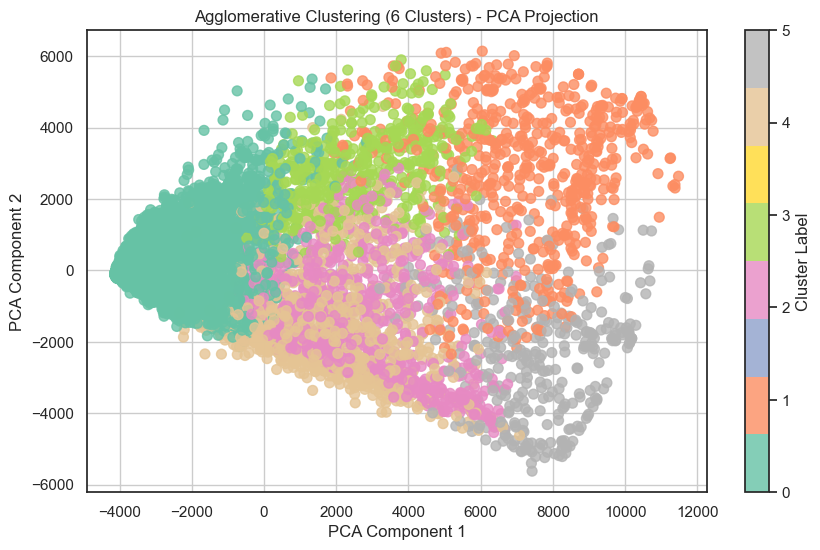

In [30]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=cluster_labels, cmap='Set2', s=50, alpha=0.8)
plt.title("Agglomerative Clustering (6 Clusters) - PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.show()

In [31]:
# Add cluster labels to  original DataFrame
df_clustered = df_winsorized.copy()
df_clustered['cluster'] = cluster_labels

In [32]:
# print cluster sizes
cluster_counts = df_clustered['cluster'].value_counts().sort_index()
print("Cluster Sizes:\n", cluster_counts)

Cluster Sizes:
 cluster
0    5311
1     620
2    1213
3     555
4     907
5     344
Name: count, dtype: int64


In [33]:
# Get the mean of each feature per cluster
cluster_profiles = df_clustered.groupby('cluster').mean()
print("Cluster Profiles (Means):")
cluster_profiles

Cluster Profiles (Means):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,782.353522,0.856776,460.216357,210.549851,246.788676,504.888302,0.443736,0.119997,0.343801,0.109691,2.263792,8.835624,2185.297497,864.121454,477.717637,0.142689,11.458106
1,4881.785194,0.967087,781.151710,492.611548,291.390016,4200.985406,0.375196,0.189357,0.262188,0.365288,9.717742,11.350000,9873.636364,3447.209968,1699.626124,0.036629,11.685484
2,966.046081,0.868590,685.704081,377.696669,306.747139,411.696203,0.527155,0.260711,0.334822,0.066062,1.333059,11.801319,7730.053211,979.805920,384.759924,0.215846,11.780709
3,4293.674222,0.974614,387.047640,199.057027,187.008036,2766.789773,0.285804,0.114188,0.195374,0.338597,8.185586,7.327928,5776.756757,1475.919489,1543.715804,0.003081,11.526126
4,1261.066316,0.924665,2616.511555,1718.240496,893.795899,471.717578,0.776683,0.509608,0.582132,0.072370,1.632856,32.886439,5595.312552,3297.824505,526.562526,0.277650,11.897464
5,3273.411611,0.948925,3649.280262,2487.666483,1259.637965,588.027237,0.862850,0.626337,0.670538,0.082792,1.941860,44.395349,10745.058140,4483.402243,1210.860022,0.232145,11.921512


The table above helps us interpretate the segments. We can extract some useful insight from this in the analysis section. 

### Summary of Unsupervised Learning methods
* **K-means++** gave us clusters that overlapped overlap significantly and were not as spread out as we would like. This, combined with the very low silhouette scores did not provide enough confidence in selecting this method for the analysis.
* **DBSCAN** found it difficult to determine enough dense regions that satisfy both the epsilon and min_samples values. This method was completely unsuccessful as it chose the best number of clusters as 1. Obviously this won't work for our analysis.
* **Hierarchical Clustering** *by means of Agglomerative clustering* was the best method used in the modelling stage. This method provided us with decent silhouette scores. For customer data, a silhouette score between 0.25 and 0.5, and this method gave us a high of 0.37 which is reasonable. This wis definitely the model of choice for this project.

In [34]:
cluster_profiles

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,782.353522,0.856776,460.216357,210.549851,246.788676,504.888302,0.443736,0.119997,0.343801,0.109691,2.263792,8.835624,2185.297497,864.121454,477.717637,0.142689,11.458106
1,4881.785194,0.967087,781.151710,492.611548,291.390016,4200.985406,0.375196,0.189357,0.262188,0.365288,9.717742,11.350000,9873.636364,3447.209968,1699.626124,0.036629,11.685484
2,966.046081,0.868590,685.704081,377.696669,306.747139,411.696203,0.527155,0.260711,0.334822,0.066062,1.333059,11.801319,7730.053211,979.805920,384.759924,0.215846,11.780709
3,4293.674222,0.974614,387.047640,199.057027,187.008036,2766.789773,0.285804,0.114188,0.195374,0.338597,8.185586,7.327928,5776.756757,1475.919489,1543.715804,0.003081,11.526126
4,1261.066316,0.924665,2616.511555,1718.240496,893.795899,471.717578,0.776683,0.509608,0.582132,0.072370,1.632856,32.886439,5595.312552,3297.824505,526.562526,0.277650,11.897464
5,3273.411611,0.948925,3649.280262,2487.666483,1259.637965,588.027237,0.862850,0.626337,0.670538,0.082792,1.941860,44.395349,10745.058140,4483.402243,1210.860022,0.232145,11.921512


### Summary key findings and insight
*Using hierarchical clusting results*
* cluster 5 has a high average amount of purchases and purchase frequency compared to the other segments. It also has the highest PURCHASES_TRX which is the average transaction amount per purchase. This data suggest this segment are our high value customers. 
* cluster 5 has a significantly high number of installment purchases compared to the other clusters. They also have a high number of one-off purchases. However, do **not** have the highest balance amount of the clusters. In addition, they have a significantly high credit limit on average. This suggests that cluster 5 customers may be more probe to high borrowing and using credit to enact their transactions.
* cluster 0 appears to be our low spenders group. They have the lowest balance amount, coupled with low purchases, one-off purchases and frequency. 
* cluster 0 has a significantly low credit limit comparatively. However, they do not have the lowest amount of minimu payments to what they owe. This suggests that, in contrast to cluster 5, this group is not to keen on using credit to make payments, though when they do use credit, they want to pay it off somewhat quickly.
* all 6 customer groups have a similar tenure length of 11 months. Cluster 5 has a marginally higher average tenure which is moderately interesting since this appears to be our high spenders group. Although the margin may not be significant enought to be insightful.

### Summary for next steps

* iterate on DBSCAN method by using HDBSCAN
* try fine-tuning the number of clusters for K-means++ further by using the Calinski-Harabasz index or Davies-Bouldin score
* try running K-Means++ on different subsets of features to test if the clusters change or become more interpretable
* noise analysis for DBSCAN/HDBSCAN. Investigate noise points (label -1) to see if they represent outliers or niche customer behaviors worth studying separately
* build dndrogram for agglomerative clustering. Can use this to explore different cut points in the dendrogram to discover alternative numbers of clusters
* compare linkage methods: I could try complete, average and single — some may suit the data structure better than ward